# Case 01 — Cay quyet dinh nong lo ra NGUONG co che  ·  *Bai L6 (Decision Tree)*

## Y tuong
Bai L6 day: cay quyet dinh chia du lieu bang cac cau hoi **"bien ≤ nguong?"**, va o moi buoc no chon
nguong lam hai nhanh con **sach** nhat (do bang **Gini** — nhanh cang thuan 1 lop thi Gini cang gan 0).
O day ta co tinh de cay **nong (max_depth=3)** de no buoc phai chon dung vai nguong *quan trong nhat*,
roi doc xem do la nguong nao.

## Vi sao chay thu nghiem nay
Toan bo Feature Engineering dua tren gia dinh "may hong theo nguong co che": mon dao ~240 phut,
chenh lech nhiet ~8.6K... Nhung do la **ta tu gia dinh**. Cay quyet dinh KHONG biet gi ve gia dinh do —
no chi nhin du lieu. Neu no **tu** chia dung vao cac nguong ay thi gia dinh duoc xac nhan **khach quan**.

## Cach doc cay (quan trong)
- Moi nut ghi: dieu kien chia · Gini · ty le mau · `class`.
- `weights: [a, b]` = tong TRONG SO cua lop 0 va lop 1 trong nut (da nhan `class_weight='balanced'`
  nen lop hong bi it duoc keo len). `b >> a` => nut nay gan nhu toan may HONG.

In [1]:
# ============================================================================
# PRELUDE DUNG CHUNG cho moi notebook trong thu muc nay.
# Muc dich: moi file TU CHAY DUOC ma khong phu thuoc notebook chinh.
#   - Nap train.csv (Day chuyen A) + test.csv (Day chuyen B)
#   - Tao lai dung 4 feature co che nhu notebook chinh (de ket qua nhat quan)
# ============================================================================
import os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42; np.random.seed(RANDOM_STATE)   # co dinh seed -> chay lai ra so giong nhau

# --- Nap du lieu: thu nhieu duong dan vi notebook nam trong thu muc con ---
CANDIDATES = ['../Data_Final/Data_Final','../Data_Final','Data_Final/Data_Final',
              '../../Data_Final/Data_Final','Data_Final','.']
DATA_DIR = next((c for c in CANDIDATES
                 if os.path.exists(os.path.join(c,'train.csv'))
                 and os.path.exists(os.path.join(c,'test.csv'))), None)
assert DATA_DIR is not None, 'Khong tim thay train.csv/test.csv'
train = pd.read_csv(os.path.join(DATA_DIR,'train.csv'))
test  = pd.read_csv(os.path.join(DATA_DIR,'test.csv'))

NUM = ['nhiet_do_moi_truong','nhiet_do_quy_trinh','toc_do_quay','momen_xoan','do_mon_dao']  # 5 bien so goc
CAT = ['loai_san_pham','ca_lam_viec']   # 2 bien phan loai goc
TARGET = 'hong_hoc'                      # nhan: 1 = hong trong ca ke tiep

# --- Feature Engineering theo CO CHE vat ly (giong het notebook chinh) ---
def add_features(df):
    d = df.copy()
    # (1) Chenh lech nhiet: co che tan nhiet kem HDF. Lay HIEU nen triet tieu offset khi hau -> giam shift.
    d['chenh_lech_nhiet'] = d['nhiet_do_quy_trinh'] - d['nhiet_do_moi_truong']
    # (2) Cong suat co (W) = momen(Nm) * van_toc_goc(rad/s); van_toc_goc = rpm*2pi/60. Co che qua tai cong suat PWF.
    d['cong_suat_co']     = d['momen_xoan'] * d['toc_do_quay'] * 2*np.pi/60.0
    # (3) Tich mon*momen: co che qua tai cang thang OSF (mon cang nhieu + momen cang lon -> cang de gay).
    d['tich_mon_momen']   = d['do_mon_dao'] * d['momen_xoan']
    # (4) osf_margin: khoang cach toi NGUONG OSF, nguong phu thuoc HANG SP (L/M/H). >0 = da vuot nguong.
    g = d['loai_san_pham'].map({'L':11000,'M':12000,'H':13000})
    d['osf_margin']       = d['tich_mon_momen'] - g
    return d

train_fe = add_features(train); test_fe = add_features(test)
y_train = train_fe[TARGET].values
y_test  = test_fe[TARGET].values

# Bo feature CUOI da chot o notebook chinh: 9 bien so + 1 bien phan loai (loai_san_pham)
FINAL_NUM = NUM + ['chenh_lech_nhiet','cong_suat_co','tich_mon_momen','osf_margin']
FINAL_CAT = ['loai_san_pham']
print('Train:', train.shape, '| Test:', test.shape,
      '| ti le hong train/test:', round(y_train.mean(),3), round(y_test.mean(),3))
print('FINAL_NUM =', FINAL_NUM)

Train: (14000, 8) | Test: (6000, 8) | ti le hong train/test: 0.074 0.08
FINAL_NUM = ['nhiet_do_moi_truong', 'nhiet_do_quy_trinh', 'toc_do_quay', 'momen_xoan', 'do_mon_dao', 'chenh_lech_nhiet', 'cong_suat_co', 'tich_mon_momen', 'osf_margin']


### 1) Huan luyen cay nong & ve cay (plot_tree)
Cay chi dung feature SO (khong can scale) de **nguong doc ra dung don vi goc** (vd 243.95 phut mon dao, doc hieu ngay).

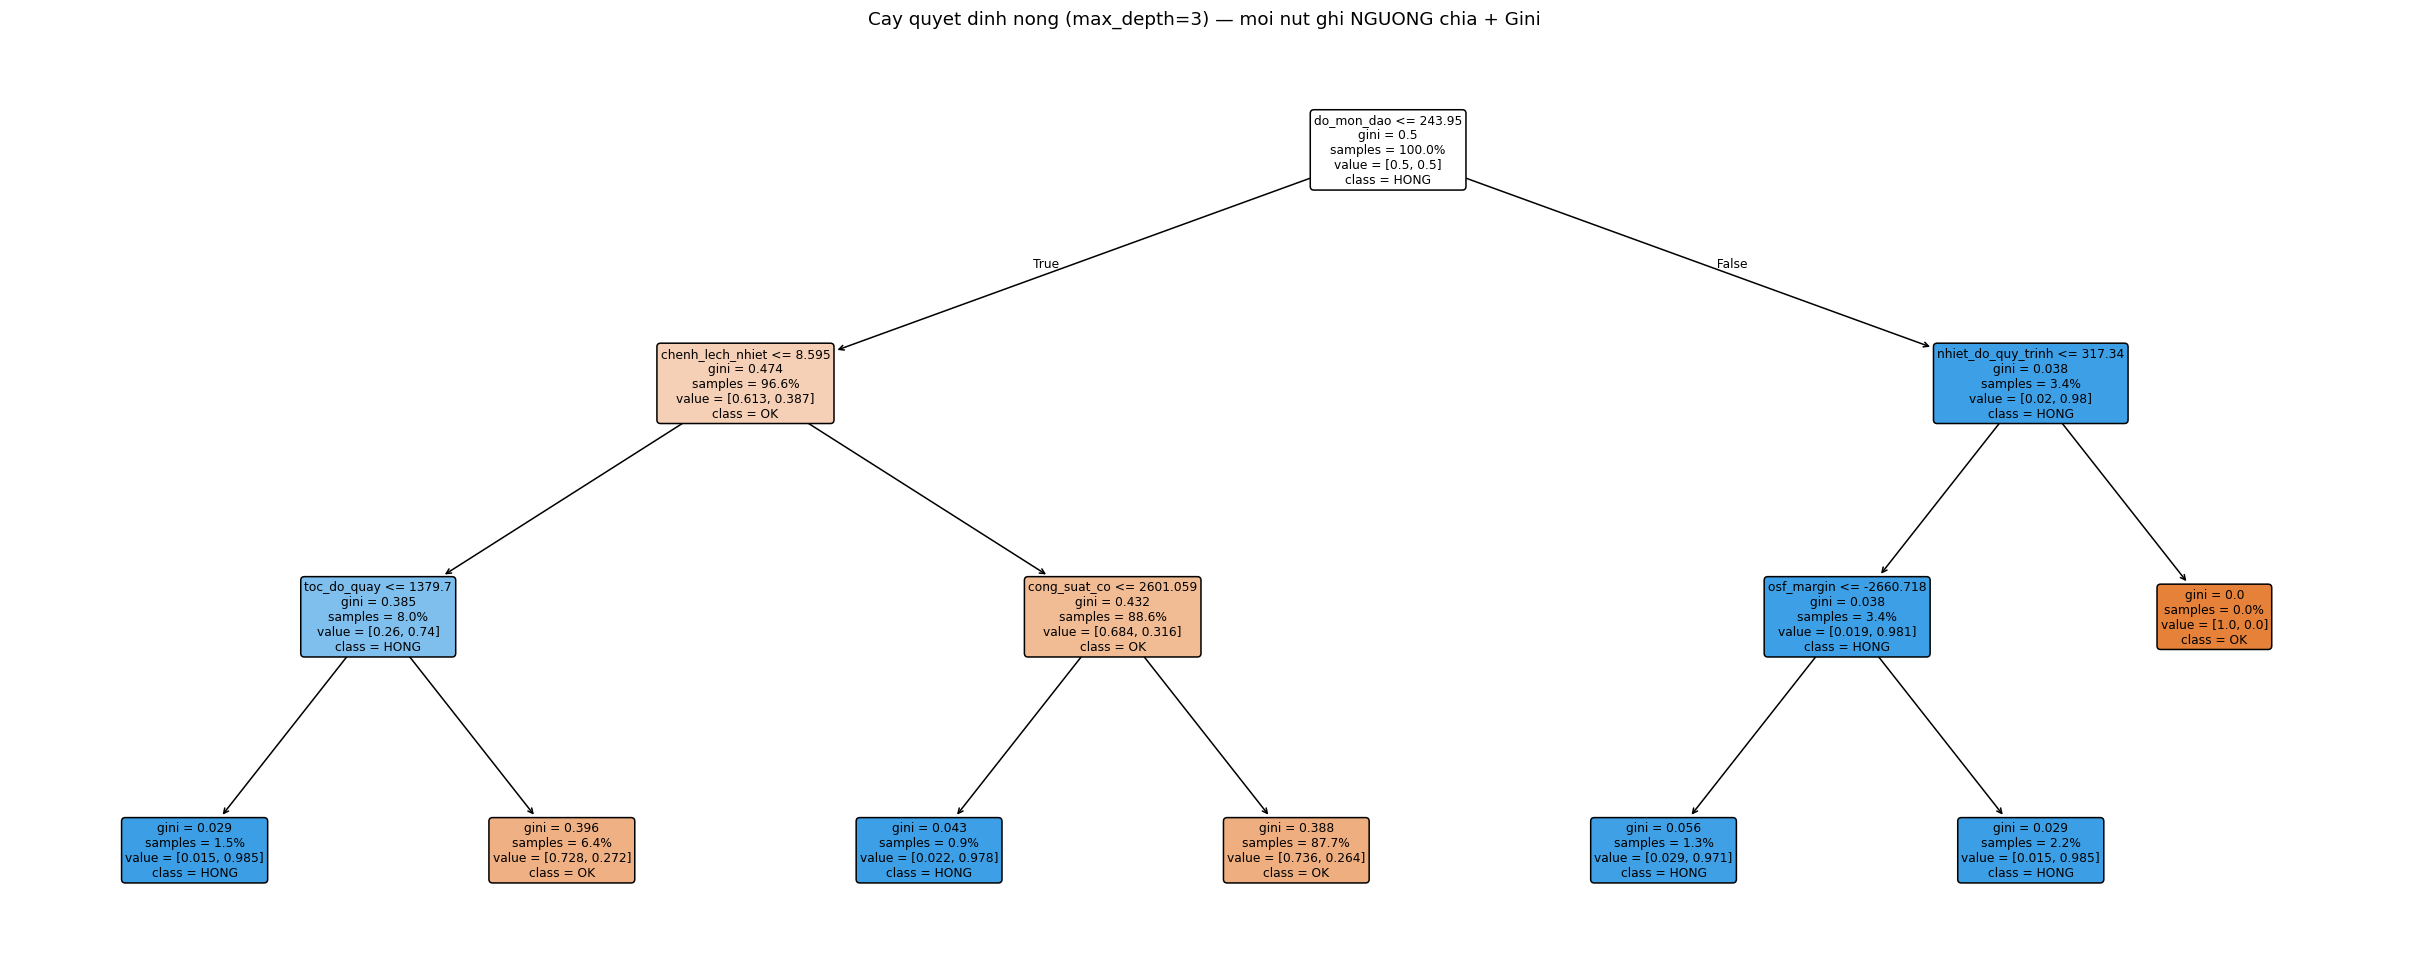

In [2]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import f1_score, average_precision_score

# max_depth=3      : ep cay nong -> chi giu vai nguong quan trong nhat (de doc, de giai thich)
# class_weight     : 'balanced' -> bu cho lop hong thieu so (~7-8%), neu khong cay se bo qua lop hong
dt = DecisionTreeClassifier(max_depth=3, class_weight='balanced',
                            random_state=RANDOM_STATE).fit(train_fe[FINAL_NUM], y_train)

fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(dt, feature_names=FINAL_NUM, class_names=['OK','HONG'],
          filled=True,        # to mau theo lop chiem uu the -> nhin phat biet nhanh hong nam dau
          rounded=True, impurity=True, proportion=True, fontsize=8, ax=ax)
ax.set_title('Cay quyet dinh nong (max_depth=3) — moi nut ghi NGUONG chia + Gini', fontsize=12)
plt.tight_layout(); plt.show()

### 2) In luat dang van ban + doi chieu voi nguong co che ta gia dinh

In [3]:
# export_text: in cay ra chu, de trich vao bao cao / doc khi khong co hinh
print(export_text(dt, feature_names=list(FINAL_NUM), show_weights=True))

# Gom tat ca nguong ma cay da chon o cac nut chia (feature>=0 nghia la nut chia, khong phai la)
print('\n--- Nguong CAY tu tim (o cac nut chia) ---')
thr_by_feat = {}
for node in range(dt.tree_.node_count):
    f = dt.tree_.feature[node]
    if f >= 0:
        thr_by_feat.setdefault(FINAL_NUM[f], []).append(round(dt.tree_.threshold[node], 2))
for k, v in thr_by_feat.items():
    print(f'  {k:18s} nguong = {sorted(set(v))}')

print('\n--- Nguong CO CHE ta GIA DINH khi lam FE (de doi chieu) ---')
print('  do_mon_dao       ~ 240 phut  (TWF: hao mon dao)')
print('  chenh_lech_nhiet ~ 8.6 K     (HDF: tan nhiet kem)')
print('  osf_margin       ~ 0         (OSF: tich_mon_momen vuot nguong theo hang SP)')
print('  cong_suat_co     : vung thap (<~2800) va cao (>~10000) deu de hong (PWF)')

|--- do_mon_dao <= 243.95
|   |--- chenh_lech_nhiet <= 8.60
|   |   |--- toc_do_quay <= 1379.70
|   |   |   |--- weights: [18.35, 1222.11] class: 1
|   |   |--- toc_do_quay >  1379.70
|   |   |   |--- weights: [473.36, 176.53] class: 0
|   |--- chenh_lech_nhiet >  8.60
|   |   |--- cong_suat_co <= 2601.06
|   |   |   |--- weights: [15.11, 672.16] class: 1
|   |   |--- cong_suat_co >  2601.06
|   |   |   |--- weights: [6440.82, 2308.44] class: 0
|--- do_mon_dao >  243.95
|   |--- nhiet_do_quy_trinh <= 317.34
|   |   |--- osf_margin <= -2660.72
|   |   |   |--- weights: [25.91, 869.06] class: 1
|   |   |--- osf_margin >  -2660.72
|   |   |   |--- weights: [25.91, 1751.70] class: 1
|   |--- nhiet_do_quy_trinh >  317.34
|   |   |--- weights: [0.54, 0.00] class: 0


--- Nguong CAY tu tim (o cac nut chia) ---
  do_mon_dao         nguong = [np.float64(243.95)]
  chenh_lech_nhiet   nguong = [np.float64(8.6)]
  toc_do_quay        nguong = [np.float64(1379.7)]
  cong_suat_co       nguong = [np.f

> ### 🔎 Doc ket qua (Case 01)
> Cay **tu chia** dung vao cac nguong ta gia dinh, du khong he duoc "mach":
>
> | Nguong cay tim | Ta gia dinh | Nhan xet |
> |---|---|---|
> | `do_mon_dao ≤ 243.95` | ~240 (TWF) | **trung** |
> | `chenh_lech_nhiet ≤ 8.60` | 8.6 (HDF) | **trung khit** |
> | `toc_do_quay ≤ 1379.70` | ~1380 | **trung** |
> | `cong_suat_co ≤ 2601` | vung PWF-thap | **dung vung** |
>
> Vi du 1 nhanh: `do_mon_dao ≤ 243.95 & chenh_lech_nhiet ≤ 8.60 & toc_do_quay ≤ 1379.70`
> -> `weights: [18.35, 1222.11]` -> gan nhu **toan may HONG**. Do chinh la co che HDF
> (nhiet chenh thap = tan nhiet kem, o toc do quay thap) ma cay tu tim ra.
>
> => Cac dac trung co che khong phai "ve cho dep": thuat toan doc lap cung xac nhan do la **ranh gioi that**.

### 3) Cay nong nay du de bao nhieu? (chi de tham chieu)

In [4]:
# Cay nong chu yeu de GIAI THICH, khong phai de dat F1 cao. Van do thu de biet no manh yeu the nao.
p = dt.predict_proba(test_fe[FINAL_NUM])[:,1]
p_tr = dt.predict_proba(train_fe[FINAL_NUM])[:,1]
ts = np.linspace(0.05, 0.9, 80)                                  # quet nguong xac suat...
thr = ts[int(np.argmax([f1_score(y_train, (p_tr>=t)) for t in ts]))]  # ...chon nguong toi uu F1 TREN TRAIN (khong nhin test)
print(f'Cay nong depth=3: AUC-PR(test)={average_precision_score(y_test,p):.3f} '
      f'| F1(test @thr-train {thr:.2f})={f1_score(y_test,(p>=thr)):.3f}')
print('Tham chieu: RandomForest (mo hinh cuoi) ~0.78. Cay nong yeu hon vi chi 3 tang,')
print('nhung bu lai cho ta NGUONG DOC DUOC — do moi la gia tri o thu nghiem nay.')

Cay nong depth=3: AUC-PR(test)=0.618 | F1(test @thr-train 0.28)=0.752
Tham chieu: RandomForest (mo hinh cuoi) ~0.78. Cay nong yeu hon vi chi 3 tang,
nhung bu lai cho ta NGUONG DOC DUOC — do moi la gia tri o thu nghiem nay.


> ### ✅ Ket luan Case 01
> Cay nong tu chia dung quanh cac nguong co che (mon dao ~244, chenh lech nhiet 8.6, toc do 1380),
> **xac nhan Feature Engineering theo co che la co co so thuc te**, khong phai suy dien chu quan.
> Cay sau hon se cho F1 cao hon nhung mat tinh giai thich; vi vay ta dung **cay nong nhu cong cu KE CHUYEN**,
> con **RandomForest/XGBoost** moi la mo hinh du doan cuoi. Khi bi hoi "sao biet mon dao 240 la nguong?" -> chi vao hinh cay.